1.Generate data and train the model

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.linalg import sqrtm

# ==============================
# [0] Global parameters (specific to 10D)
# ==============================
d = 10              # state dimension
m = 5               # control dimension
Nt = 200            # number of time steps
r_base = 5         # number of basis functions (can be increased if needed, kept same as 3D)
T_end = 1.0         # time interval [0,1]
N_traj = 3000       # number of training trajectories
batch_size = 32
lr = 5e-4
train_epochs = 150  # can be increased as needed
alpha = 1e-6        # positive definite threshold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# [1] Basis functions: phi_i(t) 
# ==============================
def phi(i, t):
    if i == 0:
        return 1.0
    if i % 2 == 1:          # cos
        k = (i + 1) // 2
        return np.cos(k * np.pi * t)
    else:                   # sin
        k = i // 2
        return np.sin(k * np.pi * t)

# ==============================
# [2] Generate a valid trajectory (with screening)
# ==============================
def generate_one_valid_trajectory(max_trial=100):
    """
    Generate a trajectory that satisfies conditions:
    1. Closed-loop positive definiteness: Q + K^T R K >= alpha*I
    2. (A,B) controllable
    3. (Q^0.5, A) observable
    Returns: list of dicts with keys: 'C','D','E','P_T','R','t','P','A','B'
             Time order: increasing from 0 to T_end, inclusive.
    """
    for _ in range(max_trial):
        # Randomly generate basis coefficients
        C = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
        D = [np.random.randn(d, m) * 0.05 for _ in range(r_base)]
        E = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]

        R = np.eye(m)
        R_inv = np.linalg.inv(R)
        P_T = np.eye(d)                     # terminal condition

        # Time-varying matrix functions
        def A(t):
            return sum((C[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, d)))

        def B(t):
            return sum((D[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, m)))

        def Q(t):
            M = sum((E[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, d)))
            return M @ M.T   # positive semi-definite

        # Time grid
        t_seq = np.linspace(0, T_end, Nt)
        dt = t_seq[1] - t_seq[0]
        h = -dt

        # Riccati right-hand side function
        def riccati_rhs(t, P):
            return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

        # Storage: start with terminal condition at t = T_end
        traj_data = [{
            'C': C, 'D': D, 'E': E,
            'P_T': P_T,
            'R': R,
            't': t_seq[-1],
            'P': P_T.copy(),
            'A': A(t_seq[-1]),
            'B': B(t_seq[-1])
        }]

        P = P_T.copy()
        valid = True

        # Backward integration from t = T_end - dt down to 0
        for idx in range(Nt-2, -1, -1):
            tk = t_seq[idx]          # target time
            # Current P corresponds to t = t_seq[idx+1]
            # Integrate one step backward (h = -dt)
            k1 = riccati_rhs(tk + dt, P)   # note: using t = tk+dt as the point for derivative evaluation
            t_mid = tk + dt + h/2
            P_mid = P + h/2 * k1
            k2 = riccati_rhs(t_mid, P_mid)
            P_mid2 = P + h/2 * k2
            k3 = riccati_rhs(t_mid, P_mid2)
            t_next = tk + dt + h      # = tk
            P_end = P + h * k3
            k4 = riccati_rhs(t_next, P_end)
            Pk = P + h/6 * (k1 + 2*k2 + 2*k3 + k4)
            Pk = (Pk + Pk.T) / 2

            # Screening conditions
            K = R_inv @ B(tk).T @ Pk

            # 1. Closed-loop positive definiteness
            if np.min(np.linalg.eigvals(Q(tk) + K.T @ R @ K)) < alpha:
                valid = False
                break

            # 2. Controllability
            C_mat = B(tk)
            for i in range(1, d):
                C_mat = np.hstack((C_mat, np.linalg.matrix_power(A(tk), i) @ B(tk)))
            if np.linalg.matrix_rank(C_mat) < d:
                valid = False
                break

            # 3. Observability (using square root of Q)
            Q_sqrt = sqrtm(Q(tk)).real
            O_mat = Q_sqrt
            for i in range(1, d):
                O_mat = np.vstack((O_mat, Q_sqrt @ np.linalg.matrix_power(A(tk), i)))
            if np.linalg.matrix_rank(O_mat) < d:
                valid = False
                break

            traj_data.append({
                'C': C, 'D': D, 'E': E,
                'P_T': P_T,
                'R': R,
                't': tk,
                'P': Pk,
                'A': A(tk),
                'B': B(tk)
            })
            P = Pk

        if valid:
            traj_data.reverse()   # now time increasing from 0 to T_end
            return traj_data

    return None
# ==============================
# [3] Build training dataset (by number of trajectories)
# ==============================
def build_training_dataset(N_traj):
    all_data = []
    traj_count = 0
    attempts = 0

    while traj_count < N_traj:
        traj = generate_one_valid_trajectory()
        attempts += 1
        if traj is not None:
            all_data.extend(traj)
            traj_count += 1

        if attempts % 100 == 0:
            print(f"Attempts to generate trajectories: {attempts}, successful: {traj_count}")

    print(f"Final generated {traj_count} trajectories, total samples: {len(all_data)}")
    return all_data

print("Start generating training dataset (10D system)...")
dataset = build_training_dataset(N_traj)
print(f"Dataset generation completed, total samples: {len(dataset)}")

# ==============================
# [4] Flatten basis coefficients
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# [5] Dataset
# ==============================
class RiccatiCoeffDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        dct = self.data[idx]
        branch = flatten_coeffs(dct['C'], dct['D'], dct['E'], dct['P_T'])
        trunk = np.array([dct['t']])
        label = dct['P'].flatten()
        return (torch.FloatTensor(branch),
                torch.FloatTensor(trunk),
                torch.FloatTensor(label))

dset = RiccatiCoeffDataset(dataset)
loader = DataLoader(dset, batch_size=batch_size, shuffle=True)

# ==============================
# [6] Dimension calculation
# ==============================
branch_dim = r_base*d*d + r_base*d*m + r_base*d*d + d*d   # 1150 (when d=10,m=5,r_base=5)
out_dim = d * d                                           # 100
print("="*60)
print(f"Dimension info: branch_dim = {branch_dim}, out_dim = {out_dim}")
print(f"Total number of P matrix elements: {d*d} ({d}×{d})")
print("="*60)

# ==============================
# [7] DeepONet model (structure specific to 10D)
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=512):
        super().__init__()
        # ========== Branch network (specifically for high-dimensional input) ==========
        self.branch = nn.Sequential(
            # First layer: adapt to high-dimensional input (1300+ dimensions)
            nn.Linear(branch_dim, 1024),
            nn.LayerNorm(1024),          # LayerNorm is more suitable for high-dimensional sparse inputs than BatchNorm
            nn.GELU(),
            nn.Dropout(0.15),            # moderate dropout
            
            # Second layer: deep feature extraction
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            
            # Third layer: reduce dimension to hidden size
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, p)
        )

        # ========== Trunk network (enhanced time dimension) ==========
        self.trunk = nn.Sequential(
            # Multi-layer feature extraction for time
            nn.Linear(1, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, p)
        )

        # ========== Fusion layer + output layer (multi-stage fusion) ==========
        # 1. Extract features after branch fusion
        self.fusion = nn.Sequential(
            nn.Linear(p, p),
            nn.LayerNorm(p),
            nn.GELU()
        )
        # 2. Output layer (two-layer mapping to mitigate dimension jump)
        self.fc1 = nn.Linear(p, p//2)
        self.fc2 = nn.Linear(p//2, out_dim)
        # 3. Global residual (direct branch input to output, used in extreme depth scenarios)
        self.global_shortcut = nn.Linear(branch_dim, out_dim)

    def forward(self, b_in, t_in):
        # 1. Branch feature extraction
        b_feat = self.branch(b_in)
        t_feat = self.trunk(t_in)
        
        # 2. Branch fusion
        fusion_feat = self.fusion(b_feat * t_feat)
        
        # 3. Output layer mapping
        out = self.fc1(fusion_feat)
        out = nn.GELU()(out)
        out = self.fc2(out)
        
        # 4. Global residual (optional, recommended for high-dimensional scenarios)
        out += 0.1 * self.global_shortcut(b_in)  # small weight to avoid dominating
        
        return out

model = DeepONet(branch_dim, out_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Print dimensions of first batch
for branch, trunk, y in loader:
    branch = branch.to(device)
    trunk = trunk.to(device)
    y = y.to(device)
    print("First batch dimensions:")
    print(f"branch: {branch.shape}, trunk: {trunk.shape}, label: {y.shape}")
    break

# ==============================
# [8] Training
# ==============================
print("\nStart calculating initial loss (model not trained)...")
model.eval()
init_total_loss = 0.0
with torch.no_grad():
    for b, t, y in loader:
        b = b.to(device)
        t = t.to(device)
        y = y.to(device)
        y_hat = model(b, t)
        loss = loss_fn(y_hat, y)
        init_total_loss += loss.item()
init_avg_loss = init_total_loss / len(loader)

print("="*60)
print(f"Epoch  0 | Initial loss (untrained): {init_avg_loss:.6f}")
print("="*60)

print("\nStart formal training...")
start_time = time.time()
model.train()
for epoch in range(1, train_epochs + 1):
    total_loss = 0.0
    for b, t, y in loader:
        b = b.to(device)
        t = t.to(device)
        y = y.to(device)
        opt.zero_grad()
        y_hat = model(b, t)
        loss = loss_fn(y_hat, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Avg Loss {avg_loss:.8f}")

end_time = time.time()
train_total_time = end_time - start_time
print(f"\nTraining completed! Total time: {train_total_time:.2f} seconds")
print("="*60)

# Save model
save_dir = os.path.join(os.getcwd(), "DRE_10D_cs")
os.makedirs(save_dir, exist_ok=True)
model_save_name = f"DeepONet_model_d{d}_epochs_{train_epochs}_cs_copy1.pth"
model_save_path = os.path.join(save_dir, model_save_name)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt.state_dict(),
    'train_epochs': train_epochs,
    'lr': lr,
    'final_loss': avg_loss
}, model_save_path)
print(f"Model saved to: {model_save_path}")

Start generating training dataset (10D system)...
Attempts to generate trajectories: 100, successful: 100
Attempts to generate trajectories: 200, successful: 200
Attempts to generate trajectories: 300, successful: 300
Attempts to generate trajectories: 400, successful: 400
Attempts to generate trajectories: 500, successful: 500
Attempts to generate trajectories: 600, successful: 600
Attempts to generate trajectories: 700, successful: 700
Attempts to generate trajectories: 800, successful: 800
Attempts to generate trajectories: 900, successful: 900
Attempts to generate trajectories: 1000, successful: 1000
Attempts to generate trajectories: 1100, successful: 1100
Attempts to generate trajectories: 1200, successful: 1200
Attempts to generate trajectories: 1300, successful: 1300
Attempts to generate trajectories: 1400, successful: 1400
Attempts to generate trajectories: 1500, successful: 1500
Attempts to generate trajectories: 1600, successful: 1600
Attempts to generate trajectories: 1700,

2.Calculation error and drawing

Model loaded successfully: DRE_10D_cs/DeepONet_model_d10_epochs_150_cs_copy1.pth
Start generating 100 test trajectories...
Attempts 100, successful trajectories so far 100
Test set generation completed: 100 trajectories
Processed 20/100 trajectories
Processed 40/100 trajectories
Processed 60/100 trajectories
Processed 80/100 trajectories
Processed 100/100 trajectories

========== Test Results ==========
e_P  (absolute) = 0.272622196
e_P^r (relative) = 0.081965061
e_x  (absolute) = 0.006767269
e_x^r (relative) = 0.002239348
e_J  (absolute) = 0.002677249
e_J^r (relative) = 0.000248427

Plotting comparison for the first test trajectory...


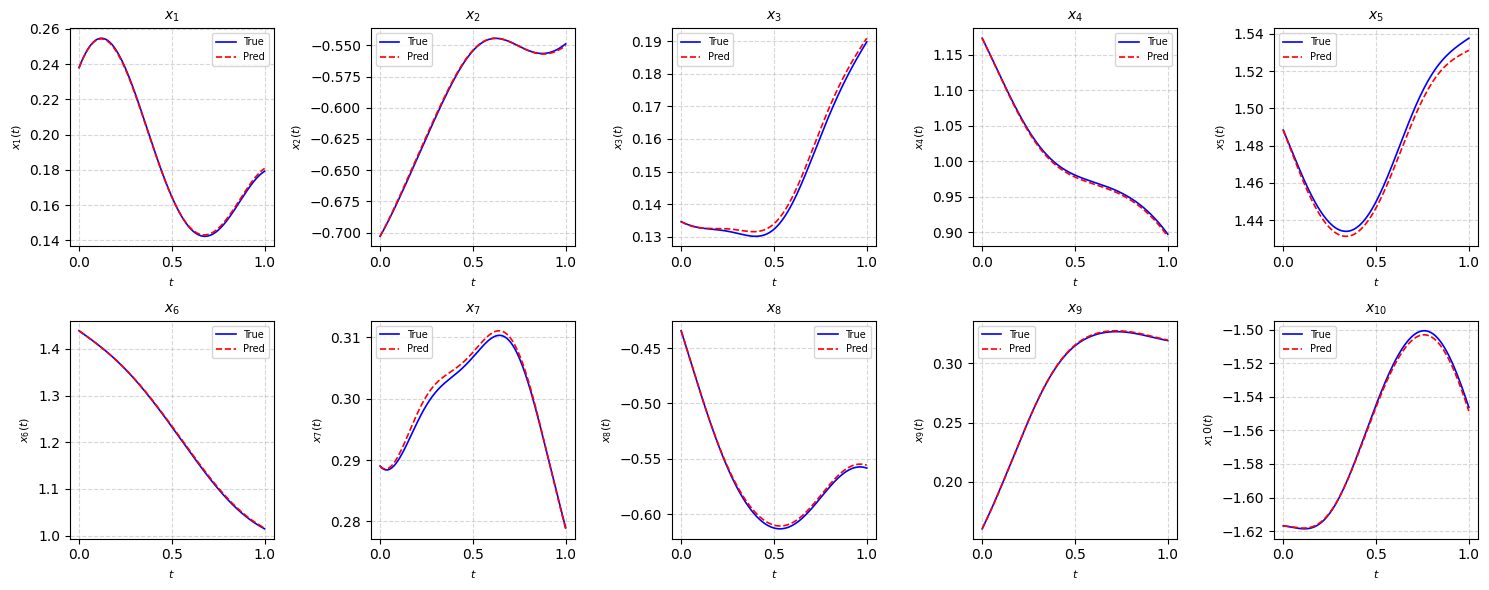

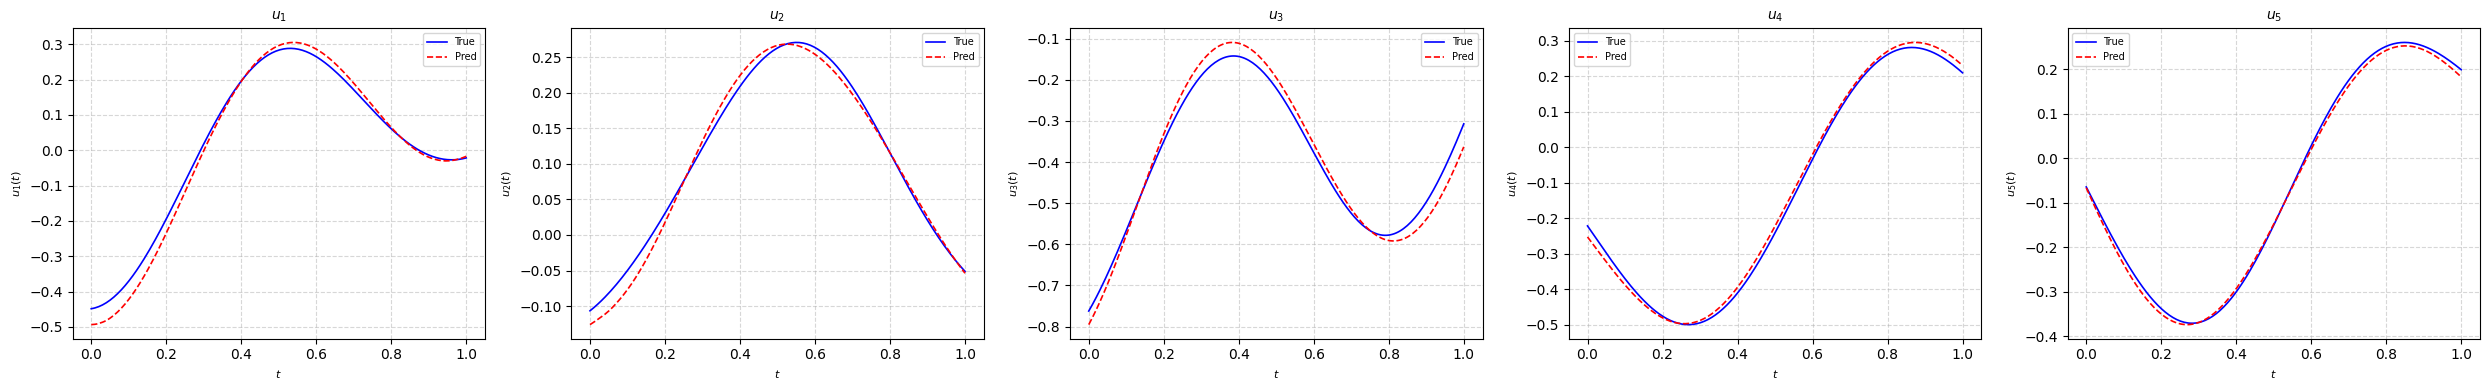

All results saved to DRE_10D_cs folder
Plot data saved to DRE_10D_cs\plot_data_10d.npz


In [26]:
import os
import numpy as np
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.linalg import sqrtm
from scipy.integrate import trapezoid

np.random.seed(68)
torch.manual_seed(68)

# ==============================+
# Global parameters (must be exactly consistent with training)
# ==============================
d = 10                     # state dimension
m = 5                      # control dimension
Nt = 200                   # number of time steps
r_base = 5                 # number of basis functions
T_end = 1.0                # time interval
alpha = 1e-6               # positive definite threshold
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# Model definition (same structure as training)
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=512):
        super().__init__()
        # Branch network (for high-dimensional input)
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, p)
        )
        # Trunk network (enhanced time dimension)
        self.trunk = nn.Sequential(
            nn.Linear(1, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, p)
        )
        # Fusion layer + output layer
        self.fusion = nn.Sequential(
            nn.Linear(p, p),
            nn.LayerNorm(p),
            nn.GELU()
        )
        self.fc1 = nn.Linear(p, p // 2)
        self.fc2 = nn.Linear(p // 2, out_dim)
        self.global_shortcut = nn.Linear(branch_dim, out_dim)

    def forward(self, b_in, t_in):
        b_feat = self.branch(b_in)
        t_feat = self.trunk(t_in)
        fusion_feat = self.fusion(b_feat * t_feat)
        out = self.fc1(fusion_feat)
        out = nn.GELU()(out)
        out = self.fc2(out)
        out += 0.1 * self.global_shortcut(b_in)  # global residual
        return out

# ==============================
# Basis functions
# ==============================
def phi(i, t):
    if i == 0:
        return 1.0
    if i % 2 == 1:          # cos
        k = (i + 1) // 2
        return np.cos(k * np.pi * t)
    else:                   # sin
        k = i // 2
        return np.sin(k * np.pi * t)

# ==============================
# Flatten basis coefficients (same as training)
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# Generate one valid test trajectory (same as training)
# ==============================
def generate_one_valid_trajectory(max_trial=100):
    """
    Generate a trajectory that satisfies conditions:
    1. Closed-loop positive definiteness: Q + K^T R K >= alpha*I
    2. (A,B) controllable
    3. (Q^0.5, A) observable
    Returns: list of dicts with keys: 'C','D','E','P_T','R','t','P','A','B'
             Time order: increasing from 0 to T_end, inclusive.
    """
    for _ in range(max_trial):
        # Randomly generate basis coefficients
        C = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
        D = [np.random.randn(d, m) * 0.05 for _ in range(r_base)]
        E = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]

        R = np.eye(m)
        R_inv = np.linalg.inv(R)
        P_T = np.eye(d)                     # terminal condition

        # Time-varying matrix functions
        def A(t):
            return sum((C[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, d)))

        def B(t):
            return sum((D[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, m)))

        def Q(t):
            M = sum((E[i] * phi(i, t) for i in range(r_base)), start=np.zeros((d, d)))
            return M @ M.T   # positive semi-definite

        # Time grid
        t_seq = np.linspace(0, T_end, Nt)
        dt = t_seq[1] - t_seq[0]
        h = -dt

        # Riccati right-hand side function
        def riccati_rhs(t, P):
            return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

        # Storage: start with terminal condition at t = T_end
        traj_data = [{
            'C': C, 'D': D, 'E': E,
            'P_T': P_T,
            'R': R,
            't': t_seq[-1],
            'P': P_T.copy(),
            'A': A(t_seq[-1]),
            'B': B(t_seq[-1])
        }]

        P = P_T.copy()
        valid = True

        # Backward integration from t = T_end - dt down to 0
        for idx in range(Nt-2, -1, -1):
            tk = t_seq[idx]          # target time
            # Current P corresponds to t = t_seq[idx+1]
            # Integrate one step backward (h = -dt)
            k1 = riccati_rhs(tk + dt, P)   # note: using t = tk+dt as the point for derivative evaluation
            t_mid = tk + dt + h/2
            P_mid = P + h/2 * k1
            k2 = riccati_rhs(t_mid, P_mid)
            P_mid2 = P + h/2 * k2
            k3 = riccati_rhs(t_mid, P_mid2)
            t_next = tk + dt + h      # = tk
            P_end = P + h * k3
            k4 = riccati_rhs(t_next, P_end)
            Pk = P + h/6 * (k1 + 2*k2 + 2*k3 + k4)
            Pk = (Pk + Pk.T) / 2

            # Screening conditions
            K = R_inv @ B(tk).T @ Pk

            # 1. Closed-loop positive definiteness
            if np.min(np.linalg.eigvals(Q(tk) + K.T @ R @ K)) < alpha:
                valid = False
                break

            # 2. Controllability
            C_mat = B(tk)
            for i in range(1, d):
                C_mat = np.hstack((C_mat, np.linalg.matrix_power(A(tk), i) @ B(tk)))
            if np.linalg.matrix_rank(C_mat) < d:
                valid = False
                break

            # 3. Observability (using square root of Q)
            Q_sqrt = sqrtm(Q(tk)).real
            O_mat = Q_sqrt
            for i in range(1, d):
                O_mat = np.vstack((O_mat, Q_sqrt @ np.linalg.matrix_power(A(tk), i)))
            if np.linalg.matrix_rank(O_mat) < d:
                valid = False
                break

            traj_data.append({
                'C': C, 'D': D, 'E': E,
                'P_T': P_T,
                'R': R,
                't': tk,
                'P': Pk,
                'A': A(tk),
                'B': B(tk)
            })
            P = Pk

        if valid:
            traj_data.reverse()   # now time increasing from 0 to T_end
            return traj_data

    return None

# ==============================
# State simulation (RK4)
# ==============================
def simulate_state_rk4(t_seq, A_list, B_list, P_list, R, x0):
    Nt = len(t_seq)
    dt = t_seq[1] - t_seq[0]
    x = x0.copy()
    x_traj = [x.copy()]
    R_inv = np.linalg.inv(R)

    for k in range(Nt - 1):
        A = A_list[k]
        B = B_list[k]
        P = P_list[k]
        K = R_inv @ B.T @ P
        A_cl = A - B @ K

        # RK4 steps
        k1 = A_cl @ x
        k2 = A_cl @ (x + 0.5 * dt * k1)
        k3 = A_cl @ (x + 0.5 * dt * k2)
        k4 = A_cl @ (x + dt * k3)
        x = x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
        x_traj.append(x.copy())

    return np.array(x_traj)

# ==============================
# Main program
# ==============================
if __name__ == "__main__":
    # 1. Load model
    model_path = "DRE_10D_cs/DeepONet_model_d10_epochs_150_cs_copy1.pth"  
    save_dir = "DRE_10D_cs"
    os.makedirs(save_dir, exist_ok=True)

    branch_dim = r_base * d * d + r_base * d * m + r_base * d * d + d * d
    out_dim = d * d

    model = DeepONet(branch_dim, out_dim).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded successfully: {model_path}")

    # 2. Generate test trajectories
    M_test = 100
    print(f"Start generating {M_test} test trajectories...")
    test_trajectories = []
    attempts = 0
    while len(test_trajectories) < M_test:
        traj = generate_one_valid_trajectory()
        attempts += 1
        if traj is not None:
            test_trajectories.append(traj)
        if attempts % 100 == 0:
            print(f"Attempts {attempts}, successful trajectories so far {len(test_trajectories)}")
    print(f"Test set generation completed: {len(test_trajectories)} trajectories")

    # 3. Error calculation
    e_P_list = []
    e_Pr_list = []
    e_x_list = []
    e_xr_list = []
    e_J_list = []
    e_Jr_list = []

    for idx, traj in enumerate(test_trajectories):
        t_seq = np.array([s['t'] for s in traj])
        Nt_actual = len(t_seq)
        C = traj[0]['C']
        D = traj[0]['D']
        E = traj[0]['E']
        P_T = traj[0]['P_T']
        R = traj[0]['R']
        R_inv = np.linalg.inv(R)

        # Build A, B, Q, P_true lists
        A_list = []
        B_list = []
        Q_list = []
        P_true_list = []
        for s in traj:
            A_list.append(s['A'])
            B_list.append(s['B'])
            M = sum((E[i] * phi(i, s['t']) for i in range(r_base)), start=np.zeros((d, d)))
            Q = M @ M.T
            Q_list.append(Q)
            P_true_list.append(s['P'])
        A_list = np.array(A_list)
        B_list = np.array(B_list)
        Q_list = np.array(Q_list)
        P_true_list = np.array(P_true_list)

        # Model prediction for P
        branch_vec = flatten_coeffs(C, D, E, P_T)
        branch_tensor = torch.FloatTensor(branch_vec).to(device)
        trunk_tensor = torch.FloatTensor(t_seq[:, None]).to(device)
        with torch.no_grad():
            P_pred_tensor = model(branch_tensor.repeat(Nt_actual, 1), trunk_tensor)
        P_pred_list = P_pred_tensor.cpu().numpy().reshape(Nt_actual, d, d)

        # Random initial state
        x0 = np.random.randn(d)

        # True and predicted state trajectories
        x_true = simulate_state_rk4(t_seq, A_list, B_list, P_true_list, R, x0)
        x_pred = simulate_state_rk4(t_seq, A_list, B_list, P_pred_list, R, x0)

        # Control inputs
        u_true = np.zeros((Nt_actual, m))
        u_pred = np.zeros((Nt_actual, m))
        for k in range(Nt_actual):
            K_true = R_inv @ B_list[k].T @ P_true_list[k]
            K_pred = R_inv @ B_list[k].T @ P_pred_list[k]
            u_true[k] = -K_true @ x_true[k]
            u_pred[k] = -K_pred @ x_pred[k]

        # Cost (trapezoidal integration)
        dt = t_seq[1] - t_seq[0]
        J_true = 0.0
        J_pred = 0.0
        for k in range(Nt_actual):
            integ_true = x_true[k] @ Q_list[k] @ x_true[k] + u_true[k] @ R @ u_true[k]
            integ_pred = x_pred[k] @ Q_list[k] @ x_pred[k] + u_pred[k] @ R @ u_pred[k]
            if k == 0 or k == Nt_actual - 1:
                J_true += 0.5 * integ_true * dt
                J_pred += 0.5 * integ_pred * dt
            else:
                J_true += integ_true * dt
                J_pred += integ_pred * dt
        J_true += x_true[-1] @ P_T @ x_true[-1]
        J_pred += x_pred[-1] @ P_T @ x_pred[-1]

        # P error
        P_err_sq = np.sum((P_true_list - P_pred_list) ** 2, axis=(1, 2))
        P_int_err = np.sqrt(trapezoid(P_err_sq, t_seq))
        P_int_true = np.sqrt(trapezoid(np.sum(P_true_list ** 2, axis=(1, 2)), t_seq))
        e_P_list.append(P_int_err)
        e_Pr_list.append(P_int_err / P_int_true if P_int_true > 0 else 0.0)

        # State error
        x_err_sq = np.sum((x_true - x_pred) ** 2, axis=1)
        x_int_err = np.sqrt(trapezoid(x_err_sq, t_seq))
        x_int_true = np.sqrt(trapezoid(np.sum(x_true ** 2, axis=1), t_seq))
        e_x_list.append(x_int_err)
        e_xr_list.append(x_int_err / x_int_true if x_int_true > 0 else 0.0)

        # Cost error
        e_J_list.append(abs(J_true - J_pred))
        e_Jr_list.append(abs(J_true - J_pred) / abs(J_true) if abs(J_true) > 0 else 0.0)

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{M_test} trajectories")

    # Average errors
    e_P_avg = np.mean(e_P_list)
    e_Pr_avg = np.mean(e_Pr_list)
    e_x_avg = np.mean(e_x_list)
    e_xr_avg = np.mean(e_xr_list)
    e_J_avg = np.mean(e_J_list)
    e_Jr_avg = np.mean(e_Jr_list)

    print("\n========== Test Results ==========")
    print(f"e_P  (absolute) = {e_P_avg:.9f}")
    print(f"e_P^r (relative) = {e_Pr_avg:.9f}")
    print(f"e_x  (absolute) = {e_x_avg:.9f}")
    print(f"e_x^r (relative) = {e_xr_avg:.9f}")
    print(f"e_J  (absolute) = {e_J_avg:.9f}")
    print(f"e_J^r (relative) = {e_Jr_avg:.9f}")
    print("==============================\n")

    # 4. Plot comparison for the first test trajectory
    print("Plotting comparison for the first test trajectory...")
    traj0 = test_trajectories[0]
    t_seq0 = np.array([s['t'] for s in traj0])
    Nt0 = len(t_seq0)
    C0, D0, E0 = traj0[0]['C'], traj0[0]['D'], traj0[0]['E']
    P_T0 = traj0[0]['P_T']
    R0 = traj0[0]['R']
    R_inv0 = np.linalg.inv(R0)

    # True and predicted P
    P_true0 = np.array([s['P'] for s in traj0])
    branch_vec0 = flatten_coeffs(C0, D0, E0, P_T0)
    branch_tensor0 = torch.FloatTensor(branch_vec0).to(device)
    trunk_tensor0 = torch.FloatTensor(t_seq0[:, None]).to(device)
    with torch.no_grad():
        P_pred0_tensor = model(branch_tensor0.repeat(Nt0, 1), trunk_tensor0)
    P_pred0 = P_pred0_tensor.cpu().numpy().reshape(Nt0, d, d)

    # A, B, Q lists
    A0 = np.array([s['A'] for s in traj0])
    B0 = np.array([s['B'] for s in traj0])
    Q0_list = []
    for s in traj0:
        M = sum((E0[i] * phi(i, s['t']) for i in range(r_base)), start=np.zeros((d, d)))
        Q0_list.append(M @ M.T)
    Q0_list = np.array(Q0_list)

    # Fixed initial state
    # np.random.seed(42)
    x0_plot = np.random.randn(d)

    # State simulation
    x_true0 = simulate_state_rk4(t_seq0, A0, B0, P_true0, R0, x0_plot)
    x_pred0 = simulate_state_rk4(t_seq0, A0, B0, P_pred0, R0, x0_plot)

    # Control inputs
    u_true0 = np.zeros((Nt0, m))
    u_pred0 = np.zeros((Nt0, m))
    for k in range(Nt0):
        K_true = R_inv0 @ B0[k].T @ P_true0[k]
        K_pred = R_inv0 @ B0[k].T @ P_pred0[k]
        u_true0[k] = -K_true @ x_true0[k]
        u_pred0[k] = -K_pred @ x_pred0[k]

    # ---------- State comparison plot (10 components, 2×5 layout) ----------
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns
    axes = axes.flatten()
    for i in range(d):  # d=10
        ax = axes[i]
        ax.plot(t_seq0, x_true0[:, i], 'b-', label='True', linewidth=1.2)
        ax.plot(t_seq0, x_pred0[:, i], 'r--', label='Pred', linewidth=1.2)
        ax.set_title(rf'$x_{{{i+1}}}$', fontsize=10)
        ax.set_xlabel('$t$', fontsize=8)
        ax.set_ylabel(f'$x_{i+1}(t)$', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7, loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "state_comparison_10d.png"), dpi=200)
    plt.show()
    
    # ---------- Control comparison plot (5 subplots, 1×5 layout) ----------
    fig, axes = plt.subplots(1, m, figsize=(5*m, 4))  # 1 row, 5 columns
    if m == 1:
        axes = [axes]
    for i in range(m):
        ax = axes[i]
        ax.plot(t_seq0, u_true0[:, i], 'b-', label='True', linewidth=1.2)
        ax.plot(t_seq0, u_pred0[:, i], 'r--', label='Pred', linewidth=1.2)
        ax.set_title(rf'$u_{{{i+1}}}$', fontsize=10)
        ax.set_xlabel('$t$', fontsize=8)
        ax.set_ylabel(rf'$u_{{{i+1}}}(t)$', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "control_comparison_subplots.png"), dpi=200)
    plt.show()
    print(f"All results saved to {save_dir} folder")

    # ------------------------------
    # 5. Save plotting data for the first trajectory (optional)
    # ------------------------------
    # Save the computed data to a .npz file for later custom plotting.
    # This avoids re-running the expensive model inference and state integration.
    plot_data = {
        't_seq': t_seq0,           # time sequence (Nt,)
        'x_true': x_true0,         # true state trajectory (Nt, d)
        'x_pred': x_pred0,         # predicted state trajectory (Nt, d)
        'u_true': u_true0,         # true control input (Nt, m)
        'u_pred': u_pred0,         # predicted control input (Nt, m)
        'd': d,                    # state dimension (10)
        'm': m                     # control dimension (5)
    }
    save_path = os.path.join(save_dir, "plot_data_10d.npz")
    np.savez(save_path, **plot_data)
    print(f"Plot data saved to {save_path}")

3.draw the picture

Data loaded successfully: time steps=200, state dimension=10, control dimension=5


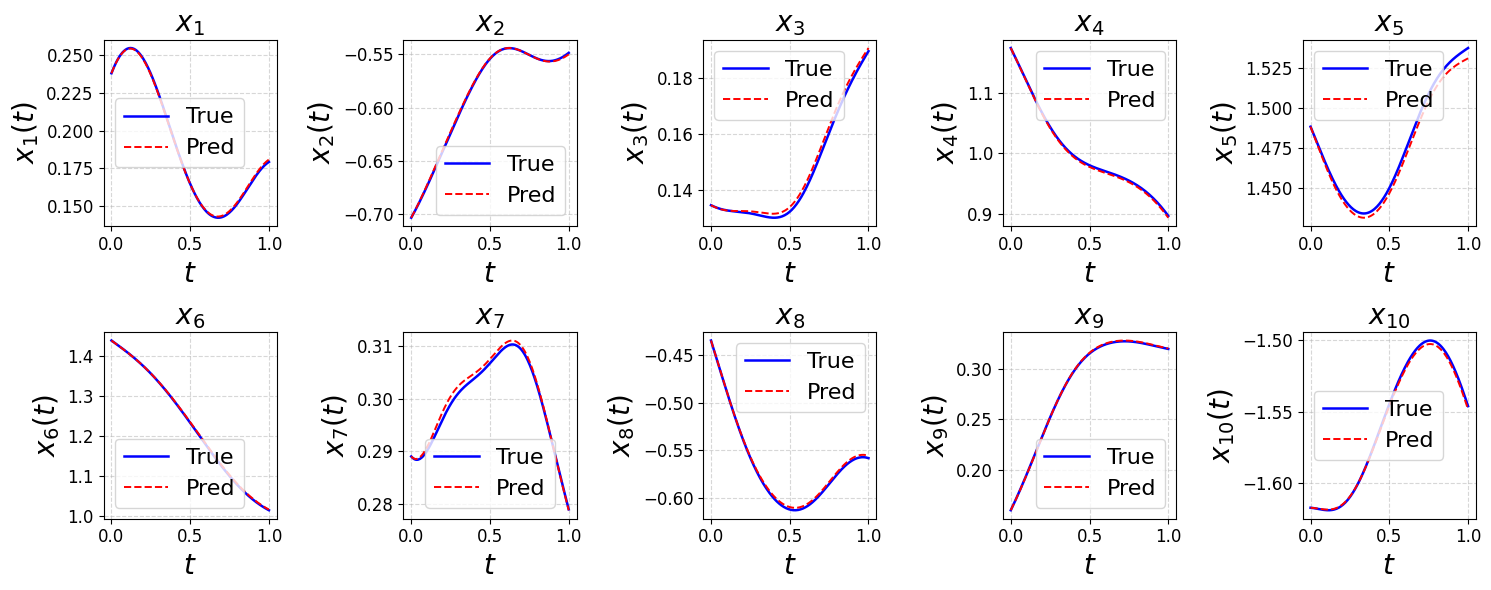

The state comparison plot has been saved: DRE_10D_cs\state_comparison_10d.png


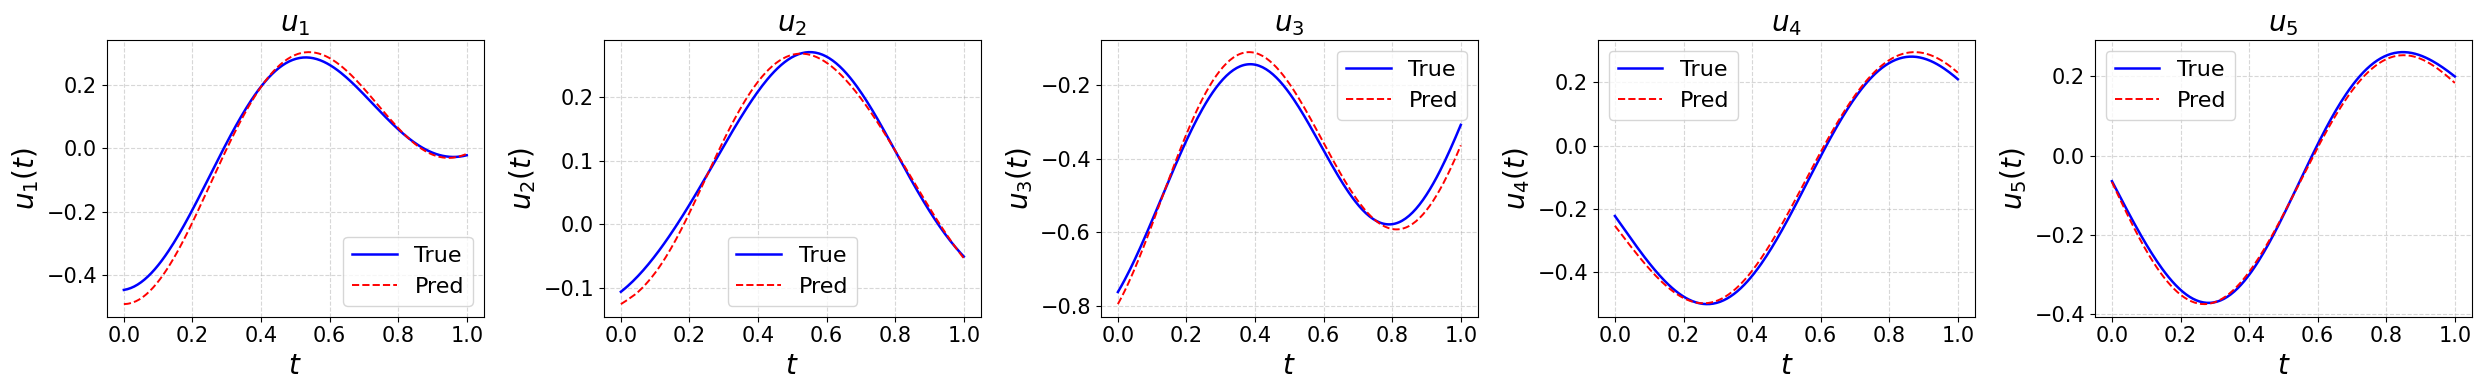

The control comparison plot has been saved: DRE_10D_cs\control_comparison_10d.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Configuration parameters (user can modify)
# ==============================
DATA_PATH = "DRE_10D_cs/plot_data_10d.npz"      # Path to the saved data file
OUTPUT_DIR = "DRE_10D_cs"                       # Directory to save output figures

STATE_PLOT_NAME = "state_comparison_10d.png"      # File name for state comparison plot
CONTROL_PLOT_NAME = "control_comparison_10d.png"  # File name for control comparison plot

# Layout for state plots (10 states -> 2 rows, 5 columns)
STATE_NROWS = 2
STATE_NCOLS = 5
STATE_FIGSIZE = (15, 6)          # 15 inches wide and 6 inches high

# Layout for control plots (5 controls -> 1 row, 5 columns)
CTRL_NROWS = 1
CTRL_NCOLS = 5
CTRL_FIGSIZE = (25, 4)           # Each subplot is 5 inches wide, total width 25 inches, height 4 inches

# Line styles
TRUE_COLOR = 'blue'              # Color for true trajectory
TRUE_LINESTYLE = '-'             # Line style for true trajectory
TRUE_LINEWIDTH = 1.8             # Line width for true trajectory
PRED_COLOR = 'red'               # Color for predicted trajectory
PRED_LINESTYLE = '--'            # Line style for predicted trajectory
PRED_LINEWIDTH = 1.4             # Line width for predicted trajectory

# Font and grid settings
TITLE_FONTSIZE = 20              # Font size for subplot titles
LABEL_FONTSIZE = 20               # Font size for axis labels
LEGEND_FONTSIZE = 16              # Font size for legend
GRID_ALPHA = 0.5                 # Transparency of grid lines
GRID_LINESTYLE = '--'            # Line style for grid

# Whether to show grid
SHOW_GRID = True

# Image resolution (DPI)
SAVE_DPI = 200

# ==============================
# Load data
# ==============================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"The data file was not found: {DATA_PATH}")

data = np.load(DATA_PATH)
t_seq = data['t_seq']               # Time sequence (Nt,)
x_true = data['x_true']             # True state trajectory (Nt, d)
x_pred = data['x_pred']             # Predicted state trajectory (Nt, d)
u_true = data['u_true']             # True control input (Nt, m)
u_pred = data['u_pred']             # Predicted control input (Nt, m)
d = int(data['d'])                  # State dimension (should be 10)
m = int(data['m'])                  # Control dimension (should be 5)

print(f"Data loaded successfully: time steps={len(t_seq)}, state dimension={d}, control dimension={m}")

# ==============================
# 1. Plot state components comparison (2 rows, 5 columns)
# ==============================
fig, axes = plt.subplots(STATE_NROWS, STATE_NCOLS, figsize=STATE_FIGSIZE)
axes = axes.flatten()

for i in range(d):
    ax = axes[i]
    ax.plot(t_seq, x_true[:, i], color=TRUE_COLOR, linestyle=TRUE_LINESTYLE,
            linewidth=TRUE_LINEWIDTH, label='True')
    ax.plot(t_seq, x_pred[:, i], color=PRED_COLOR, linestyle=PRED_LINESTYLE,
            linewidth=PRED_LINEWIDTH, label='Pred')
    ax.set_title(rf'$x_{{{i+1}}}$', fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('$t$', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(rf'$x_{{{i+1}}}(t)$', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    if SHOW_GRID:
        ax.grid(True, linestyle=GRID_LINESTYLE, alpha=GRID_ALPHA)
    ax.legend(fontsize=LEGEND_FONTSIZE, loc='best')

# Hide any unused subplots (if d < STATE_NROWS*STATE_NCOLS)
for i in range(d, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, STATE_PLOT_NAME), dpi=SAVE_DPI)
plt.show()
print(f"The state comparison plot has been saved: {os.path.join(OUTPUT_DIR, STATE_PLOT_NAME)}")

# ==============================
# 2. Plot control input comparison (1 row, 5 columns)
# ==============================
fig, axes = plt.subplots(CTRL_NROWS, CTRL_NCOLS, figsize=CTRL_FIGSIZE)
if m == 1:
    axes = [axes]

for i in range(m):
    ax = axes[i]
    ax.plot(t_seq, u_true[:, i], color=TRUE_COLOR, linestyle=TRUE_LINESTYLE,
            linewidth=TRUE_LINEWIDTH, label='True')
    ax.plot(t_seq, u_pred[:, i], color=PRED_COLOR, linestyle=PRED_LINESTYLE,
            linewidth=PRED_LINEWIDTH, label='Pred')
    ax.set_title(rf'$u_{{{i+1}}}$', fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('$t$', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(rf'$u_{{{i+1}}}(t)$', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if SHOW_GRID:
        ax.grid(True, linestyle=GRID_LINESTYLE, alpha=GRID_ALPHA)
    ax.legend(fontsize=LEGEND_FONTSIZE)
    

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, CONTROL_PLOT_NAME), dpi=SAVE_DPI)
plt.show()
print(f"The control comparison plot has been saved: {os.path.join(OUTPUT_DIR, CONTROL_PLOT_NAME)}")

4.Time

Using device: cuda
Model loaded successfully: DRE_10D_cs/DeepONet_model_d10_epochs_150_cs_copy1.pth
Generating 50 fixed random systems...

Testing Nt = 50 ...
  Performing RK4 test...
    RK4 completed 10/50 samples
    RK4 completed 20/50 samples
    RK4 completed 30/50 samples
    RK4 completed 40/50 samples
    RK4 completed 50/50 samples
    RK4 average time: 10.2135 ms
  Performing DeepONet batch test...
    DeepONet average time: 0.0667 ms

Testing Nt = 100 ...
  Performing RK4 test...
    RK4 completed 10/50 samples
    RK4 completed 20/50 samples
    RK4 completed 30/50 samples
    RK4 completed 40/50 samples
    RK4 completed 50/50 samples
    RK4 average time: 27.0038 ms
  Performing DeepONet batch test...
    DeepONet average time: 0.1248 ms

Testing Nt = 150 ...
  Performing RK4 test...
    RK4 completed 10/50 samples
    RK4 completed 20/50 samples
    RK4 completed 30/50 samples
    RK4 completed 40/50 samples
    RK4 completed 50/50 samples
    RK4 average time: 31.7016 

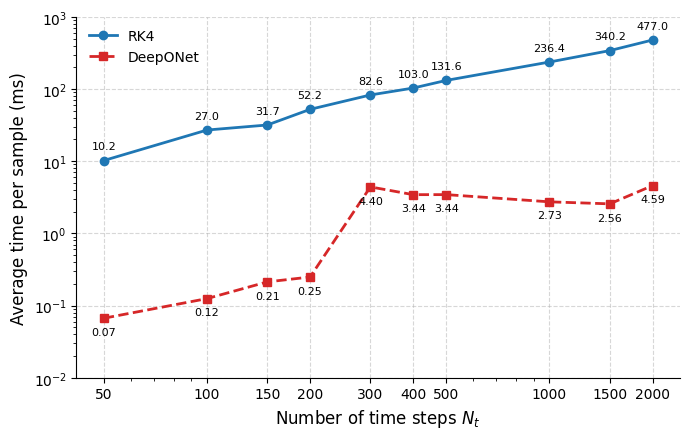


Figure saved to DRE_10D_cs/speed_vs_Nt.png

========== Results Summary ==========
Nt     RK4 (ms)     DeepONet (ms)   Speedup 
50     10.2135      0.0667          153.06  
100    27.0038      0.1248          216.44  
150    31.7016      0.2126          149.11  
200    52.2292      0.2485          210.22  
300    82.6342      4.4002          18.78   
400    103.0402     3.4360          29.99   
500    131.5950     3.4401          38.25   
1000   236.3780     2.7333          86.48   
1500   340.2025     2.5628          132.75  
2000   476.9686     4.5871          103.98  


In [1]:
# ==================== Modified main script (with data saving) ====================
import os
import time
import numpy as np
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set random seeds for reproducibility
np.random.seed(113)
torch.manual_seed(113)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(113)

# ==============================
# Global parameters (consistent with training)
# ==============================
d = 10
m = 5
r_base = 5
T_end = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
# Basis functions
# ==============================
def phi(i, t):
    return np.cos(i * np.pi * t)

# ==============================
# Flatten coefficients (C, D, E, P_T)
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# Recover coefficients from flattened vector
# ==============================
def unflatten_coeffs(vec):
    idx = 0
    C = [vec[idx:idx+d*d].reshape(d, d) for _ in range(r_base)]
    idx += r_base * d * d
    D = [vec[idx:idx+d*m].reshape(d, m) for _ in range(r_base)]
    idx += r_base * d * m
    E = [vec[idx:idx+d*d].reshape(d, d) for _ in range(r_base)]
    idx += r_base * d * d
    P_T = vec[idx:idx+d*d].reshape(d, d)
    return C, D, E, P_T

# ==============================
# Randomly generate a set of coefficients (same as training, no screening)
# ==============================
def generate_random_coeffs():
    C = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
    D = [np.random.randn(d, m) * 0.05 for _ in range(r_base)]
    E = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
    P_T = np.eye(d)
    return C, D, E, P_T

# ==============================
# Generate fixed test set (flattened coefficient vectors)
# ==============================
def generate_fixed_dataset(num_samples):
    branch_list = []
    for _ in range(num_samples):
        C, D, E, P_T = generate_random_coeffs()
        branch_list.append(flatten_coeffs(C, D, E, P_T))
    return np.stack(branch_list)  # (num_samples, branch_dim)

# ==============================
# DeepONet model definition (exactly the same as training)
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=512):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, p)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, p)
        )
        self.fusion = nn.Sequential(
            nn.Linear(p, p),
            nn.LayerNorm(p),
            nn.GELU()
        )
        self.fc1 = nn.Linear(p, p//2)
        self.fc2 = nn.Linear(p//2, out_dim)
        self.global_shortcut = nn.Linear(branch_dim, out_dim)

    def forward(self, b_in, t_in):
        b_feat = self.branch(b_in)
        t_feat = self.trunk(t_in)
        fusion_feat = self.fusion(b_feat * t_feat)
        out = self.fc1(fusion_feat)
        out = nn.GELU()(out)
        out = self.fc2(out)
        out += 0.1 * self.global_shortcut(b_in)
        return out

# ==============================
# Load trained model
# ==============================
def load_trained_model(model_path):
    branch_dim = r_base*d*d + r_base*d*m + r_base*d*d + d*d  # 5*100 + 5*50 + 5*100 + 100 = 1350
    out_dim = d * d
    model = DeepONet(branch_dim, out_dim).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    filtered_state_dict = {k: v for k, v in state_dict.items()
                           if 'running_mean' not in k and 'running_var' not in k and 'num_batches_tracked' not in k}
    model.load_state_dict(filtered_state_dict, strict=False)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
    return model

# ==============================
# RK4 solver for Riccati (for a single system, returns total time)
# ==============================
def solve_riccati_rk4(coeff_vec, t_grid):
    start = time.perf_counter()
    C, D, E, P_T = unflatten_coeffs(coeff_vec)
    R = np.eye(m)
    R_inv = np.linalg.inv(R)

    def A(t):
        return sum(C[i] * phi(i, t) for i in range(r_base))
    def B(t):
        return sum(D[i] * phi(i, t) for i in range(r_base))
    def Q(t):
        M = sum(E[i] * phi(i, t) for i in range(r_base))
        return M @ M.T

    def riccati_rhs(t, P):
        return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

    dt = t_grid[1] - t_grid[0]
    h = -dt
    P = P_T.copy()
    for k in range(len(t_grid)-2, -1, -1):
        tk = t_grid[k+1]
        k1 = riccati_rhs(tk, P)
        t_mid = tk + h/2
        P_mid = P + (h/2) * k1
        k2 = riccati_rhs(t_mid, P_mid)
        P_mid2 = P + (h/2) * k2
        k3 = riccati_rhs(t_mid, P_mid2)
        t_next = t_grid[k]
        P_end = P + h * k3
        k4 = riccati_rhs(t_next, P_end)
        P = P + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        P = (P + P.T) / 2
    elapsed = time.perf_counter() - start
    return elapsed

# ==============================
# DeepONet batch inference (forward pass for all samples and all time points at once)
# Returns (total time, average time per sample)
# ==============================
def deeponet_batch_inference(model, branch_vectors, t_grid_torch):
    num_samples = branch_vectors.shape[0]
    Nt = t_grid_torch.shape[0]
    branch_dim = branch_vectors.shape[1]
    branch_expanded = branch_vectors.repeat_interleave(Nt, dim=0)
    t_expanded = t_grid_torch.repeat(num_samples, 1)

    # Warm-up
    with torch.no_grad():
        _ = model(branch_expanded[:min(1000, branch_expanded.shape[0])],
                  t_expanded[:min(1000, branch_expanded.shape[0])])

    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(branch_expanded, t_expanded)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    avg_per_sample_ms = elapsed / num_samples * 1000   # ms per sample
    return elapsed, avg_per_sample_ms

# ==============================
# Main program
# ==============================
if __name__ == "__main__":
    # 1. Set paths (modify according to your actual save path)
    model_path = "DRE_10D_cs/DeepONet_model_d10_epochs_150_cs_copy1.pth"   
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file does not exist: {model_path}")
    model = load_trained_model(model_path)

    # 2. Generate fixed test system set (shared across all Nt)
    NUM_SAMPLES = 50   # adjust based on GPU memory
    print(f"Generating {NUM_SAMPLES} fixed random systems...")
    fixed_branch_vectors = generate_fixed_dataset(NUM_SAMPLES)   # (NUM_SAMPLES, branch_dim)

    # 3. Define list of time steps to test
    Nt_list = [50, 100, 150, 200, 300, 400, 500, 1000, 1500, 2000]
    rk4_times = []      # average RK4 time per Nt (ms)
    donet_times = []    # average DeepONet time per Nt (ms)

    for Nt in Nt_list:
        print(f"\nTesting Nt = {Nt} ...")
        t_grid_np = np.linspace(0, T_end, Nt)
        t_grid_torch = torch.linspace(0, T_end, Nt).view(-1, 1).to(device)

        # RK4 test (sample by sample)
        print("  Performing RK4 test...")
        rk4_sample_times = []
        for i in range(NUM_SAMPLES):
            t = solve_riccati_rk4(fixed_branch_vectors[i], t_grid_np)
            rk4_sample_times.append(t)
            if (i+1) % 10 == 0:
                print(f"    RK4 completed {i+1}/{NUM_SAMPLES} samples")
        rk4_avg = np.mean(rk4_sample_times) * 1000   # convert to ms
        rk4_times.append(rk4_avg)
        print(f"    RK4 average time: {rk4_avg:.4f} ms")

        # DeepONet batch test
        print("  Performing DeepONet batch test...")
        _, donet_avg = deeponet_batch_inference(model, torch.tensor(fixed_branch_vectors, dtype=torch.float32).to(device), t_grid_torch)
        donet_times.append(donet_avg)
        print(f"    DeepONet average time: {donet_avg:.4f} ms")

    # 4. Save data for later plotting
    save_dir = "DRE_10D_cs"
    os.makedirs(save_dir, exist_ok=True)
    data_save_path = os.path.join(save_dir, "speed_data.npz")
    np.savez(data_save_path, Nt_list=np.array(Nt_list), rk4_times=np.array(rk4_times), donet_times=np.array(donet_times))
    print(f"\nData saved to {data_save_path}")

    # 5. Plot and save figure (optional, can be skipped if using separate plotting script)
    plt.figure(figsize=(7, 4.5))
    color_rk4 = '#1f77b4'
    color_don = '#d62728'
    plt.plot(Nt_list, rk4_times, marker='o', linestyle='-', color=color_rk4, linewidth=2, markersize=6, label='RK4')
    plt.plot(Nt_list, donet_times, marker='s', linestyle='--', color=color_don, linewidth=2, markersize=6, label='DeepONet')
    plt.xlabel('Number of time steps $N_t$', fontsize=12)
    all_times = rk4_times + donet_times
    min_time = min(t for t in all_times if t > 0)
    max_time = max(all_times)
    lower = 10 ** math.floor(math.log10(min_time))
    upper = 10 ** math.ceil(math.log10(max_time))
    plt.yscale('log')
    plt.xscale('log')
    plt.xticks(Nt_list, [str(nt) for nt in Nt_list])
    plt.ylim(lower, upper)
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))
    ax.xaxis.set_major_locator(ticker.FixedLocator(Nt_list))
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.grid(False, which='minor')
    plt.ylabel('Average time per sample (ms)', fontsize=12)
    plt.legend(fontsize=10, frameon=False)
    for x, y1, y2 in zip(Nt_list, rk4_times, donet_times):
        plt.annotate(f'{y1:.1f}', (x, y1), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
        offset = -12
        if abs(y1 - y2) / y1 < 0.2:
            offset = -18
        plt.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", xytext=(0, offset), ha='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "speed_vs_Nt.png"), dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved to {save_dir}/speed_vs_Nt.png")

    # Print results table
    print("\n========== Results Summary ==========")
    print(f"{'Nt':<6} {'RK4 (ms)':<12} {'DeepONet (ms)':<15} {'Speedup':<8}")
    for nt, rk, dn in zip(Nt_list, rk4_times, donet_times):
        speedup = rk / dn if dn > 0 else np.inf
        print(f"{nt:<6} {rk:<12.4f} {dn:<15.4f} {speedup:<8.2f}")
    print("=======================================")